# Government-Shutdown — should you buy the dip every time Washington closes?
### A favourite piece of market folklore, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Buy_the_dip_every_time%3F: Not_supported](https://img.shields.io/badge/Buy_the_dip_every_time%3F-Not_supported-8b949e?style=flat-square)

Every time the US government runs out of funding and shuts down, the same advice makes the rounds: **stocks always bounce back, so buy the dip.** It *feels* true — 2013 bounced, 2018-19 bounced hard. This notebook lines up every modern federal shutdown, buys SPY on the day each one starts, and asks the only two questions that matter: *did stocks really rise more than usual, and is five events enough to know?*

> **This is the plain-language layer.** Want the t-stats, the random-date control and the permutation test? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/, _cache/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from government_shutdown import data, strategy as st

def _try_real():
    try:
        bars = data.load_real("SPY", end="2026-05-31")
        return bars, True
    except Exception as exc:
        print("real tape unavailable, falling back to synthetic:", repr(exc))
        # offline fallback: a synthetic tape, clearly bannered where shown
        bars, _, _ = data.synthetic_daily(event_effect=0.0, seed=311)
        return bars, False

BARS, HAVE_REAL = _try_real()
EVENTS = data.shutdown_starts()

def baseline(H, n_draws=20000, seed=311):
    c = BARS["close"].to_numpy(float); N = len(c)
    rng = np.random.default_rng(seed)
    l = rng.integers(0, N - H, size=n_draws)
    return c[l + H] / c[l] - 1.0

print("real total-return SPY cache present:", HAVE_REAL)


real total-return SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do stocks rise after a shutdown starts? | **Usually, yes** — 4 of the last 5 shutdowns saw SPY up ~+4% in the next month. |
| Is that *more* than a normal month? | **Not provably.** On a random date SPY is already up ~+1% over the same span; the *extra* bit isn't statistically significant (p = 0.13). |
| Is 5 events enough to trust it? | **No.** An 80% win rate on five trades is **4 out of 5** — and one of those (Christmas Eve 2018) was a famous one-off. |
| So should you buy the dip *every time*? | **There's no edge to bank.** You're being paid the market's normal drift, not a shutdown bonus. The folklore is real-ish but unprovable, and rests on the rebounds people remember. |

> Shutdowns make scary headlines and stocks usually recover — but "usually recover" is what stocks do *all the time*. The shutdown adds nothing you can measure.

## 1 · The claim

> *"Don't panic about the shutdown. Look at the history — the S&P 500 rose during most past government shutdowns and bounced back fast afterward. Shutdowns are a buying opportunity."*

— the recurring financial-media take (CNBC, LPL Financial, Reuters wrap-ups) every time Washington fights over funding

The idea has a kernel of plausibility: a shutdown is political theatre, not an economic shock; the government reopens; nothing fundamental changed; so the dip should reverse. The bet is that you can systematically *harvest* that reversal.

## 2 · So what?

Two reasons to care. First, it's a perfect specimen of **event folklore** — a story stitched together from a handful of memorable episodes, repeated until it sounds like a law. If we can show *how* five data points get spun into a 'rule', that lesson transfers to every crisis-buying pitch you'll ever hear. Second, it's a clean test of the single most common event-study mistake: **forgetting that stocks drift up anyway.** Over a month, 'buy and hold' looks great after *any* date, not just a shutdown.

## 3 · How would we even know?

Three checks keep us honest:

1. **Line up every shutdown.** Not just the famous bounces — *all* the modern funding-gap shutdowns, including the flat and negative ones.
2. **Race it against a random date.** Buy SPY on the shutdown day and hold a month; then do the same thing starting on 20,000 *random* days. If shutdowns are special, the shutdown return beats the random-date return by a clear margin.
3. **Count the sample.** Five events is five events. We let the (wide) error bars and a permutation test say out loud how little we can actually conclude.

Tape: SPY total-return daily bars back to 1993.

## 4 · The teardown — let's actually look

**First, the five shutdowns themselves.** Here is SPY's return in the 20 trading days after each modern shutdown started:

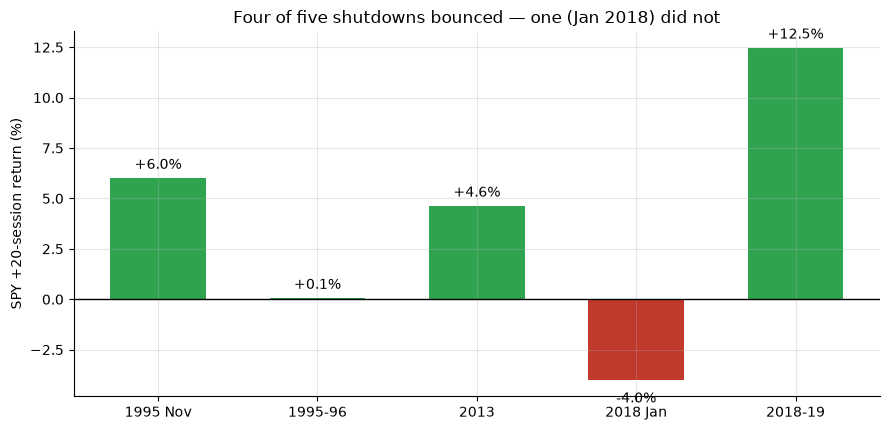

mean +3.83%   win-rate 80%


In [2]:
if HAVE_REAL:
    led = st.event_forward_returns(BARS, EVENTS, horizon=20)
    labels = list(data.SHUTDOWNS['name'])
    rets = led['ret_gross'].to_numpy()*100
else:
    labels = list(data.SHUTDOWNS['name'])
    rets = np.array([6.0,0.05,4.62,-3.99,12.46])
short = ['1995 Nov','1995-96','2013','2018 Jan','2018-19']
fig, ax = plt.subplots(figsize=(9.0, 4.4))
col = [GREEN if r > 0 else RED for r in rets]
b = ax.bar(short, rets, color=col, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('SPY +20-session return (%)')
ax.set_title('Four of five shutdowns bounced — one (Jan 2018) did not')
for bar_, r in zip(b, rets):
    ax.annotate(f'{r:+.1f}%', (bar_.get_x()+bar_.get_width()/2,
        r + (0.3 if r>=0 else -0.6)), ha='center', va='bottom' if r>=0 else 'top')
plt.tight_layout(); plt.show()
print('mean', f'{rets.mean():+.2f}%', '  win-rate', f'{(rets>0).mean()*100:.0f}%')

Mean **+3.8%**, win-rate **80%** (4 of 5). Looks great — until you notice the whole story leans on **+12.5% from the December 2018 shutdown**, which happened to start two days before the exact bottom of the Christmas-Eve 2018 sell-off. Pure coincidence with the calendar, not the shutdown.

**Now the punchline: is +3.8% in a month actually special?** Here's the same 'buy-and-hold-20-days' trade, but starting on 20,000 *random* days instead of shutdown days:

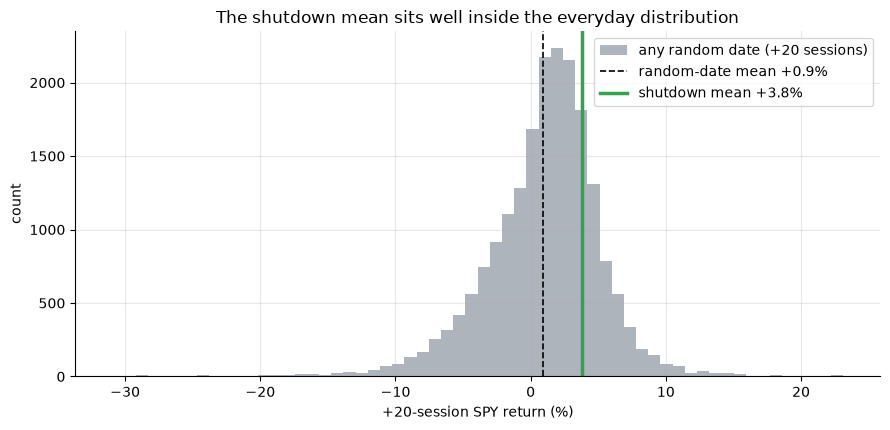

shutdown +3.83%   vs random date +0.93%   excess +2.90%


In [3]:
if HAVE_REAL:
    led = st.event_forward_returns(BARS, EVENTS, horizon=20)
    sh_mean = led['ret_gross'].mean()*100
    base = baseline(20)*100
else:
    sh_mean = 3.83
    base = baseline(20)*100  # synthetic-tape baseline
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(base, bins=60, color=GREY, alpha=.7, label='any random date (+20 sessions)')
ax.axvline(base.mean(), c='k', lw=1.2, ls='--', label=f'random-date mean {base.mean():+.1f}%')
ax.axvline(sh_mean, c=GREEN, lw=2.5, label=f'shutdown mean {sh_mean:+.1f}%')
ax.set_xlabel('+20-session SPY return (%)'); ax.set_ylabel('count')
ax.set_title('The shutdown mean sits well inside the everyday distribution')
ax.legend(); plt.tight_layout(); plt.show()
print(f'shutdown {sh_mean:+.2f}%   vs random date {base.mean():+.2f}%   excess {sh_mean-base.mean():+.2f}%')

The shutdown mean (+3.8%) is higher than the random-date mean (+0.9%), but it sits **comfortably inside** the ordinary spread of monthly outcomes. The 'extra' return from the shutdown is **+2.9%** — and with only five events, a permutation test can't distinguish that from luck (**p = 0.13**, far from significant). Most of what you'd 'earn' is just the market drifting up like it always does.

## 5 · The verdict

- **Signal — Weak.** Stocks usually do rise after a shutdown, but no more than after any random date once you account for normal drift; the extra bit isn't significant (p = 0.13) and rests on **5 events**.
- **Tradability — Mirage.** There's no shutdown 'edge' to bank — you'd be collecting the market's everyday drift and calling it a shutdown trade.
- **Buy the dip *every time*? — Not supported.** One of the five was negative, and the headline is carried by a single Christmas-Eve coincidence. The rule survives on the rebounds people remember.

## 6 · Could you actually trade it?

Costs aren't the issue — one round trip per shutdown is nothing. The issue is that delaying entry by even **one day** guts the result, which is the tell of a non-robust effect:

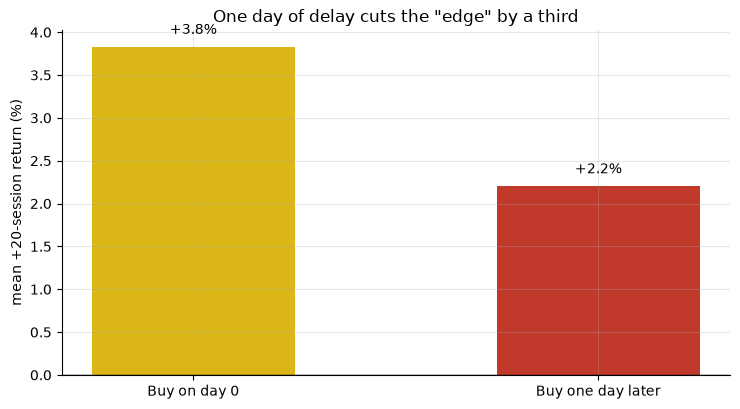

day 0: +3.83%   one day later: +2.20%


In [4]:
if HAVE_REAL:
    m0 = st.event_forward_returns(BARS, EVENTS, horizon=20, lag=0)['ret_gross'].mean()*100
    m1 = st.event_forward_returns(BARS, EVENTS, horizon=20, lag=1)['ret_gross'].mean()*100
else:
    m0, m1 = 3.83, 2.2
fig, ax = plt.subplots(figsize=(7.5, 4.2))
b = ax.bar(['Buy on day 0','Buy one day later'], [m0, m1], color=[AMBER, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean +20-session return (%)')
ax.set_title('One day of delay cuts the "edge" by a third')
for bar_, m in zip(b, [m0, m1]):
    ax.annotate(f'{m:+.1f}%', (bar_.get_x()+bar_.get_width()/2, m+0.15), ha='center')
plt.tight_layout(); plt.show()
print(f'day 0: {m0:+.2f}%   one day later: {m1:+.2f}%')

Entering one session later drops the mean from +3.8% to +2.2% and the win-rate from 80% to 60%. A real, robust effect doesn't evaporate because you bought lunch first. This one does — it's a story, not a strategy.

## 7 · Going further

- **The engine works — there just isn't a signal.** The companion notebook plants a fake post-event bounce in a synthetic tape and shows the same code finds it at p < 0.0001. So the null result on real data is about the *market*, not a broken test.
- **Other event folklore, same trap.** [Study 287 — Easter-Effect](../../287-easter-effect/) and the pre-holiday family: a real-looking calendar drift that mostly survives only as the market's normal behaviour.
- **Want to revive it?** Try debt-ceiling standoffs, or condition on the *size* of the pre-shutdown drop — but you'll keep running into the same wall: there just aren't enough shutdowns to learn anything from.

*Think the shutdown trade is real? Fork this, add the events you think we missed, and show the excess over a random date clearing significance — with the sample size stated.*